In [310]:
import os
import matplotlib.pyplot as plt
from tensorflow.python.summary.summary_iterator import summary_iterator

In [2]:
def get_tensorboard_data(logdir):
    data = {'steps': [], 'train_loss': [], 'train_ctc_loss': [], 'train_cel_loss': [], 
            'test_loss': [], 'test_ctc_loss': [], 'test_cel_loss': [], 'CER': []}

    for file in os.listdir(logdir):
        if 'events.out.tfevents' in file:
            for summary in summary_iterator(os.path.join(logdir, file)):
                for v in summary.summary.value:
                    # print(v.tag.strip() == 'CER')
                    if v.tag == 'train_loss':  # Replace with your actual tag
                        data['steps'].append(summary.step)
                        data['train_loss'].append(v.simple_value)
                    elif v.tag == 'train_ctc_loss':
                        data['train_ctc_loss'].append(v.simple_value)
                    elif v.tag == 'train_cel_loss':
                        data['train_cel_loss'].append(v.simple_value)
                    elif v.tag == 'test_loss':  # Replace with your actual tag
                        data['test_loss'].append(v.simple_value)
                    elif v.tag == 'test_ctc_loss':
                        data['test_ctc_loss'].append(v.simple_value)
                    elif v.tag == 'test_cel_loss':
                        data['test_cel_loss'].append(v.simple_value)
                    elif v.tag == 'CER':
                        data['CER'].append(v.simple_value)
    return data

In [354]:
# Provide the path to your TensorBoard log directory
logdir = 'runs/Jun26_08-04-19_splinter'
# logdir = 'runs/Apr29_09-09-21_splinter/'
# logdir = 'runs/Feb14_22-14-31_splinter/'
tb_data = get_tensorboard_data(logdir)

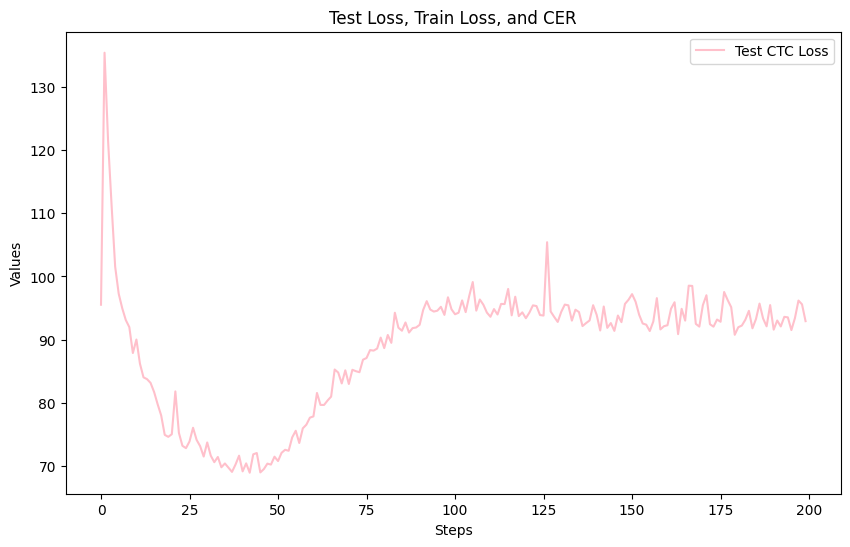

In [364]:
offset = 200

# Plotting
plt.figure(figsize=(10, 6))

# plt.plot(tb_data['steps'][offset:][:], tb_data['test_loss'][offset:][:], label='Test Loss', color='blue')
plt.plot(tb_data['steps'][:offset][:], tb_data['test_ctc_loss'][:offset][:], label='Test CTC Loss', color='pink')
# plt.plot(tb_data['steps'][offset:][:], tb_data['test_cel_loss'][offset:][:], label='Test CEL Loss', color='black')
# plt.plot(tb_data['steps'][:offset][:], tb_data['train_ctc_loss'][:offset][:], label='Train CTC Loss', color='orange')
# plt.plot(tb_data['steps'][offset:], tb_data['train_loss'][offset:], label='Train Loss', color='green')
# plt.plot(tb_data['steps'][offset:][:], tb_data['train_cel_loss'][offset:][:], label='Train CEL Loss', color='cyan')
# plt.plot(tb_data['steps'][offset:], tb_data['CER'][offset:], label='CER', color='red')

plt.xlabel('Steps')
plt.ylabel('Values')
plt.title('Test Loss, Train Loss, and CER')
plt.legend()
# plt.yscale('log')

plt.show()

In [303]:
logdir = 'runs/May28_08-21-31_splinter/'
# logdir = 'runs/May05_03-35-18_splinter/'
# logdir = 'runs/Feb14_22-14-31_splinter/'
tb_data = get_tensorboard_data(logdir)

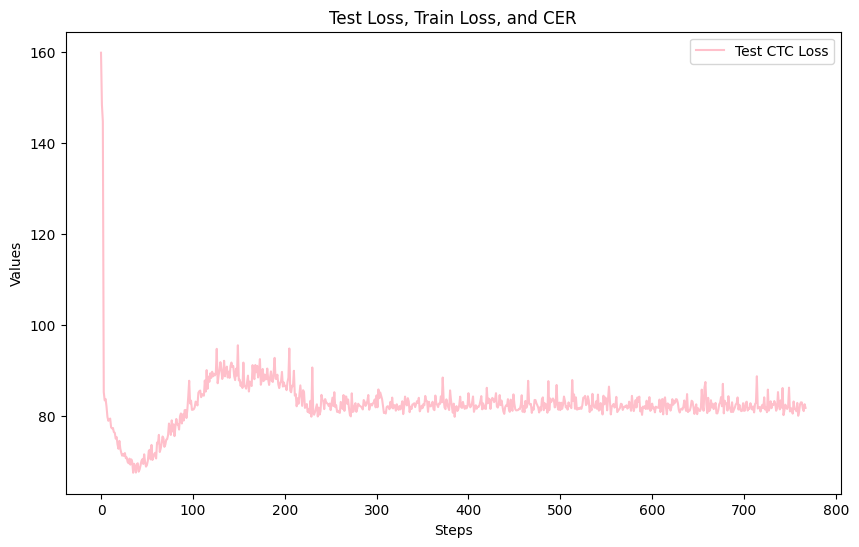

In [304]:
offset = 0

# Plotting
plt.figure(figsize=(10, 6))

# plt.plot(tb_data['steps'][offset:][:], tb_data['test_loss'][offset:][:], label='Test Loss', color='blue')
plt.plot(tb_data['steps'][offset:][:], tb_data['test_ctc_loss'][offset:][:], label='Test CTC Loss', color='pink')
# plt.plot(tb_data['steps'][offset:][:], tb_data['test_cel_loss'][offset:][:], label='Test CEL Loss', color='black')
# plt.plot(tb_data['steps'][offset:][:], tb_data['train_ctc_loss'][offset:][:], label='Train CTC Loss', color='orange')
# plt.plot(tb_data['steps'][offset:], tb_data['train_loss'][offset:], label='Train Loss', color='green')
# plt.plot(tb_data['steps'][offset:][:], tb_data['train_cel_loss'][offset:][:], label='Train CEL Loss', color='cyan')
# plt.plot(tb_data['steps'][offset:], tb_data['CER'][offset:], label='CER', color='red')

plt.xlabel('Steps')
plt.ylabel('Values')
plt.title('Test Loss, Train Loss, and CER')
plt.legend()
# plt.yscale('log')

plt.show()

In [163]:
print(tb_data['CER'][75], tb_data['train_loss'][75], tb_data['train_ctc_loss'][75])

19.0 852.5780029296875 1585.2095947265625


In [311]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import os

In [312]:
remove_channels = []

In [317]:
def remove_drift(signal, fs):
    b, a = scipy.signal.butter(3, 2, 'highpass', fs=fs)
    return scipy.signal.filtfilt(b, a, signal)

def notch(signal, freq, sample_frequency):
    b, a = scipy.signal.iirnotch(freq, 30, sample_frequency)
    return scipy.signal.filtfilt(b, a, signal)

def notch_harmonics(signal, freq, sample_frequency):
    for harmonic in range(1,8):
        signal = notch(signal, freq*harmonic, sample_frequency)
    return signal

def subsample(signal, new_freq, old_freq):
    times = np.arange(len(signal))/old_freq
    sample_times = np.arange(0, times[-1], 1/new_freq)
    result = np.interp(sample_times, times, signal)
    return result

def apply_to_all(function, signal_array, *args, **kwargs):
    results = []
    for i in range(signal_array.shape[1]):
        results.append(function(signal_array[:,i], *args, **kwargs))
    return np.stack(results, 1)

def load_utterance(base_dir, index, limit_length=False, debug=False, text_align_directory=None, is_silent=None):
    index = int(index)
    raw_emg = np.load(os.path.join(base_dir, f'{index}_emg.npy'))
    # before = os.path.join(base_dir, f'{index-1}_emg.npy')
    # after = os.path.join(base_dir, f'{index+1}_emg.npy')
    raw_emg = raw_emg.T
    raw_emg = apply_to_all(subsample, raw_emg, 1000, 5000)

    # if os.path.exists(before):
    #     raw_emg_before = np.load(before)
    #     raw_emg_before = apply_to_all(subsample, raw_emg_before, 1000, 5000)
    # else:
    #     raw_emg_before = np.zeros([0,raw_emg.shape[1]])
    # if os.path.exists(after):
    #     raw_emg_after = np.load(after)
    #     raw_emg_after = apply_to_all(subsample, raw_emg_after, 1000, 5000)
    # else:
    #     raw_emg_after = np.zeros([0,raw_emg.shape[1]])

    # x = np.concatenate([raw_emg_before, raw_emg, raw_emg_after], 0)
    x = raw_emg
    x = apply_to_all(notch_harmonics, x, 60, 1000)
    x = apply_to_all(remove_drift, x, 1000)
    # x = x[raw_emg_before.shape[0]:x.shape[0]-raw_emg_after.shape[0],:]
    emg = x

    if emg.shape[1] == 20:
        for c in remove_channels:
            emg[:, int(c)] = 0


    return emg

In [333]:
base_dir = 'patient_2_data/closed_vocab/silent/0/'
emg = np.load(base_dir+"356_emg.npy")
for c in remove_channels:
    emg[:, int(c)] = 0

In [334]:
emg = emg.T

In [335]:
emg.shape

(22465, 32)

In [331]:
new_emg = emg

In [336]:
new_emg = load_utterance(base_dir, 356)

In [337]:
new_emg.shape

(4493, 32)

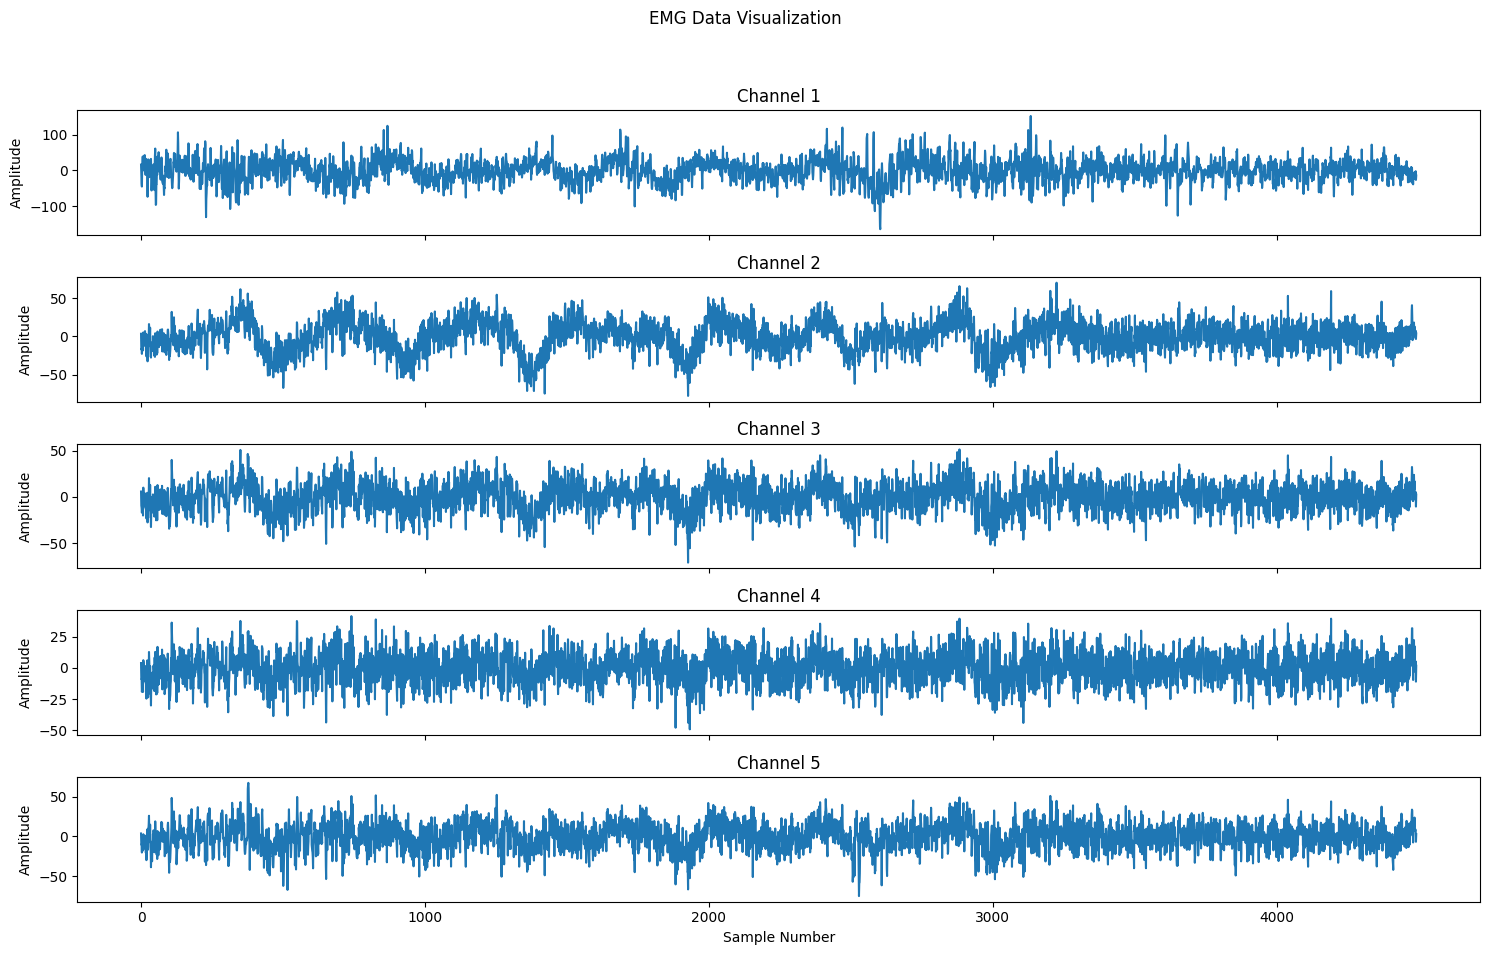

In [339]:
# Create a figure and a set of subplots
fig, axs = plt.subplots(5, 1, figsize=(15, 10), sharex=True)

# Set the title for the entire figure
fig.suptitle('EMG Data Visualization')

# Loop through each channel
axis = 0
for i in range(5):
    # Plot each channel on a separate subplot
    if i not in remove_channels:
        axs[axis].plot(new_emg[:, i])
        axs[axis].set_title(f'Channel {i+1}')
        axs[axis].set_ylabel('Amplitude')
        axis += 1

# Set common labels
plt.xlabel('Sample Number')

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show the plot
plt.show()

/tmp/ipykernel_4176796/281751479.py:21: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


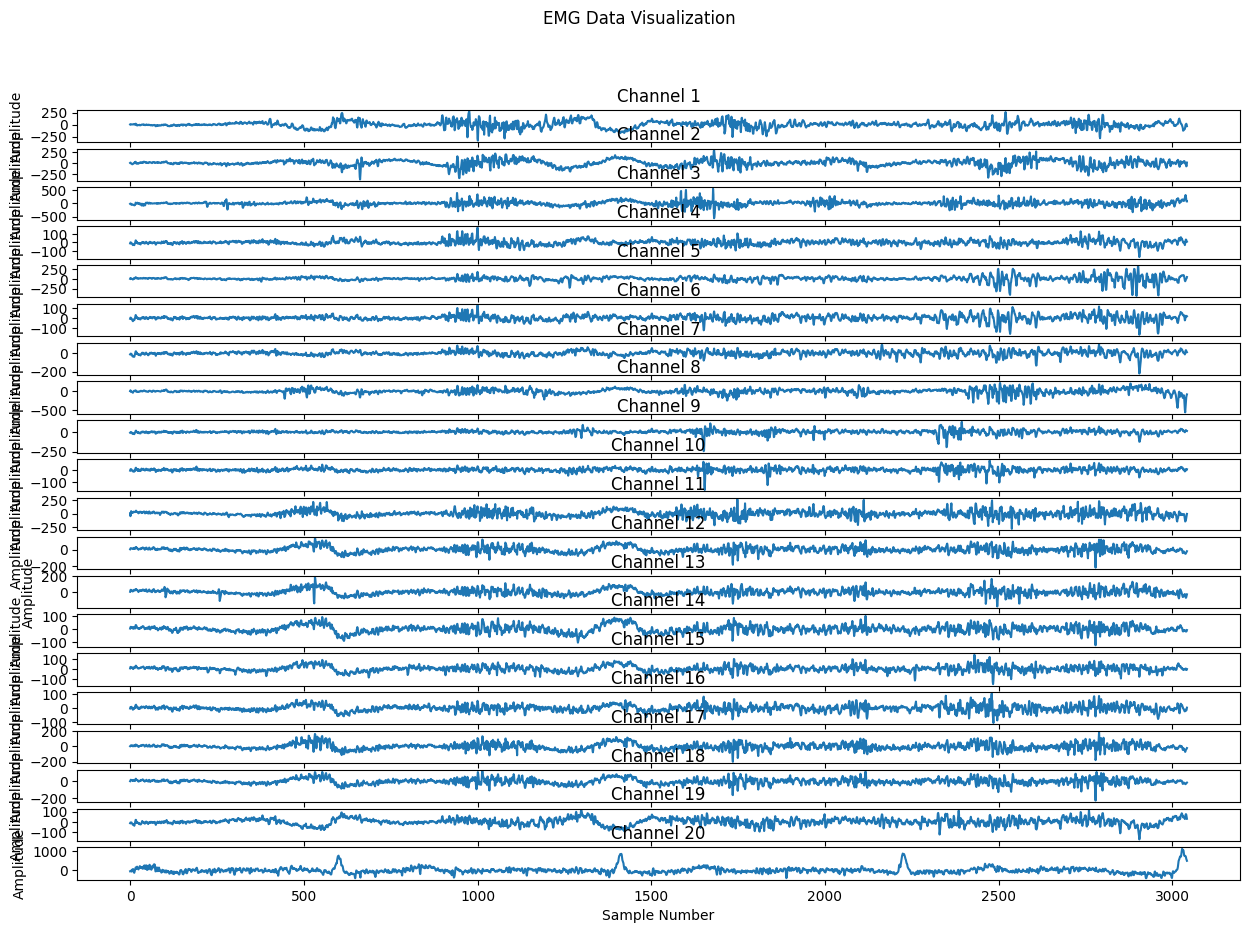

In [151]:
# Create a figure and a set of subplots
fig, axs = plt.subplots(20, 1, figsize=(15, 10), sharex=True)

# Set the title for the entire figure
fig.suptitle('EMG Data Visualization')

# Loop through each channel
axis = 0
for i in range(20):
    # Plot each channel on a separate subplot
    if i not in remove_channels:
        axs[axis].plot(new_emg[:, i])
        axs[axis].set_title(f'Channel {i+1}')
        axs[axis].set_ylabel('Amplitude')
        axis += 1

# Set common labels
plt.xlabel('Sample Number')

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show the plot
plt.show()